# **DATA ANALYSIS**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Data import 
data = pd.read_csv('synthetic_dataset.csv')

In [3]:
# Check data columns  
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 752 entries, 0 to 751
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           752 non-null    object 
 1   ICI_start    752 non-null    object 
 2   age          752 non-null    int64  
 3   gender       752 non-null    object 
 4   cancer_type  752 non-null    object 
 5   ICI_type     752 non-null    object 
 6   AKI          752 non-null    int64  
 7   AKI_date     109 non-null    object 
 8   death_flag   752 non-null    int64  
 9   final_date   752 non-null    object 
 10  cr_0m        752 non-null    float64
 11  cr_3m        634 non-null    float64
 12  cr_12m       572 non-null    float64
 13  cr_24m       460 non-null    float64
 14  cr_36m       369 non-null    float64
 15  cr_60m       180 non-null    float64
dtypes: float64(6), int64(3), object(7)
memory usage: 94.1+ KB


## **0. Data Quality Check**

In [4]:
# Conversion of dates into datetime format 
data['ICI_start'] = pd.to_datetime(data['ICI_start'])
data['final_date'] = pd.to_datetime(data['final_date'])
data['AKI_date'] = pd.to_datetime(data['AKI_date'])

In [5]:
# Check that all the dates are valid and measurements happen before end of follow-up or death
def data_quality_check(df):

    """
    Performs data quality and chronological integrity checks on the clinical dataset.  
    Validates three critical temporal assumptions to ensure robust survival analysis:
    1. The final follow-up date (or death) occurs strictly after ICI initiation.
    2. AKI diagnosis dates (if present) fall within the active follow-up window.
    3. Longitudinal serum creatinine (sCr) measurements are not recorded after a patient's final follow-up date.

    Args:
        df (pd.DataFrame): The clinical dataset containing the variables.

    Returns:
        None (Prints a formatted report to the console).
    """
    
    print('DATA QUALITY CHECK')
    print('-' * 50)
    
    # 1. Final date must happen after ICI start 
    invalid_dates = df[df['final_date'] < df['ICI_start']]
    invalid_dates_ids = invalid_dates['ID'].tolist()
    
    print(f'Patients with final date before ICI start: {len(invalid_dates)}')
    if invalid_dates_ids:
        print(f'IDs: {invalid_dates_ids}')
    
    # 2. AKI date (if present) must be between ICI start and Final date
    has_aki = df[df['AKI'] == 1]
    invalid_aki_dates = has_aki[(has_aki['AKI_date'] < has_aki['ICI_start']) |  (has_aki['AKI_date'] > has_aki['final_date'])]
    invalid_aki_ids = invalid_aki_dates['ID'].tolist()
    
    print(f'Patients with AKI date outside follow-up range: {len(invalid_aki_dates)}')
    if invalid_aki_ids:
        print(f'IDs: {invalid_aki_ids}')
    
    # 3. sCr measurements must happen before final date 
    time_stamps = [3, 12, 24, 36, 60]
    invalid_cr_total = 0
    invalid_cr_details = {} 
    
    for t in time_stamps:
        visit_dates = df['ICI_start'] + pd.DateOffset(months=t)
        
        # Find sCr with visit date after the end of follow-up 
        anomalies = df[(df[f'cr_{t}m'].notnull()) & (visit_dates > df['final_date'])]
        
        if not anomalies.empty:
            anomalous_ids = anomalies['ID'].tolist()
            invalid_cr_details[f'{t}m'] = anomalous_ids
            invalid_cr_total += len(anomalous_ids)
            
    print(f'sCr measurements after end of follow-up: {invalid_cr_total}')
    if invalid_cr_details:
        for month, ids in invalid_cr_details.items():
            print(f'Month {month}, IDs: {ids}')
            
    print('-' * 50)
data_quality_check(data)

DATA QUALITY CHECK
--------------------------------------------------
Patients with final date before ICI start: 0
Patients with AKI date outside follow-up range: 0
sCr measurements after end of follow-up: 0
--------------------------------------------------


## **1. EXPLORATORY DATA ANALYSIS (EDA)**

In the first phase, **general insights** about the dataset are extracted to have an overview for the following analysis.

In [6]:
# Set colors 
AKI_palette = ['#4C72B0', '#C44E52']
gender_palette = ['#66b3ff', '#ff9999']

# Set theme 
sns.set_theme(style="whitegrid")

### **1A.** General information

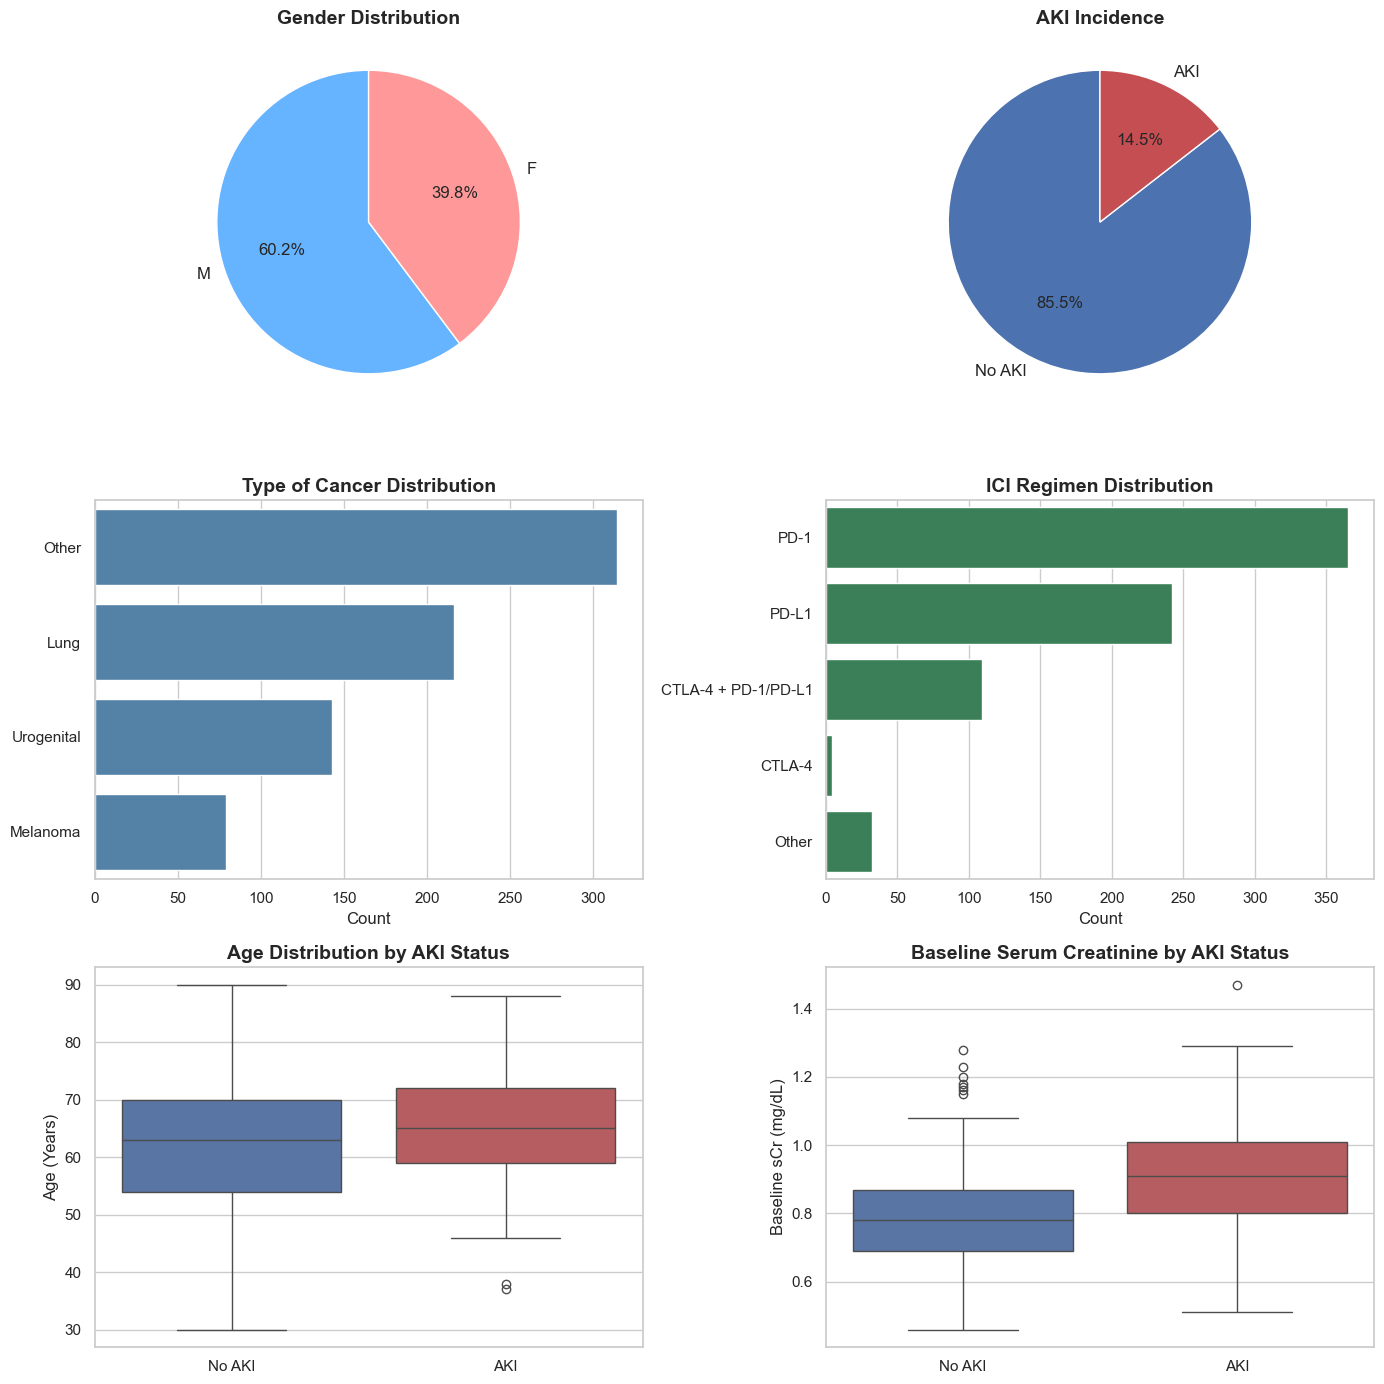

In [7]:
def plot_eda(df):

    """
    Generates a 3x2 panel of Exploratory Data Analysis (EDA) visualizations.
    Provides a clinical overview of the cohort, illustrating:
    - demographic distributions (Gender)
    - clinical characteristics (Cancer Type, ICI Regimen), 
    - Incidence of the primary outcome (AKI). 
    Additionally, compares continuous baseline metrics (Age, Baseline Serum Creatinine) stratified by AKI status.

    Args:
        df (pd.DataFrame): The clinical dataset.

    Returns:
        None (Displays a matplotlib figure with 6 subplots).
    """
    
    # Copy of the dataset mapping AKI label to 0 (No AKI) and 1 (AKI)
    plot_df = df.copy()
    plot_df['AKI_label'] = plot_df['AKI'].map({0: 'No AKI', 1: 'AKI'})

    # 3 x 2 grid 
    fig, axes = plt.subplots(3, 2, figsize=(14, 14))

    # Row 1: Gender and AKI 
    plot_df['gender'].value_counts().plot.pie(autopct='%1.1f%%', colors=gender_palette, ax=axes[0, 0], startangle=90, textprops={'fontsize': 12})
    axes[0, 0].set_ylabel('')
    axes[0, 0].set_title('Gender Distribution', fontsize=14, fontweight='bold')
    
    plot_df['AKI_label'].value_counts().plot.pie(autopct='%1.1f%%', colors=AKI_palette, ax=axes[0, 1], startangle=90, textprops={'fontsize': 12})
    axes[0, 1].set_ylabel('')
    axes[0, 1].set_title('AKI Incidence', fontsize=14, fontweight='bold')
    
    # Row 2: Type of cancer and Type of ICI 
    sns.countplot(data=plot_df, y='cancer_type', color='steelblue', ax=axes[1, 0])
    axes[1, 0].set_title('Type of Cancer Distribution', fontsize=14, fontweight='bold')
    axes[1, 0].set_ylabel('')
    axes[1, 0].set_xlabel('Count')
    
    sns.countplot(data=plot_df, y='ICI_type', color='seagreen', ax=axes[1, 1])
    axes[1, 1].set_title('ICI Regimen Distribution', fontsize=14, fontweight='bold')
    axes[1, 1].set_ylabel('')
    axes[1, 1].set_xlabel('Count')
    
    # Row 3: Age and Baseline Creatinine  
    sns.boxplot(data=plot_df, x='AKI_label', y='age', hue='AKI_label', palette=AKI_palette, legend=False, ax=axes[2, 0])
    axes[2, 0].set_title('Age Distribution by AKI Status', fontsize=14, fontweight='bold')
    axes[2, 0].set_xlabel('')
    axes[2, 0].set_ylabel('Age (Years)')
    
    sns.boxplot(data=plot_df, x='AKI_label', y='cr_0m', hue='AKI_label', palette=AKI_palette, legend=False, ax=axes[2, 1])
    axes[2, 1].set_title('Baseline Serum Creatinine by AKI Status', fontsize=14, fontweight='bold')
    axes[2, 1].set_xlabel('')
    axes[2, 1].set_ylabel('Baseline sCr (mg/dL)')
    
    # Space optimization 
    plt.tight_layout()
    plt.show()

plot_eda(data)

### **Comment**

The cohort is composed mainly of **male** patients (60.2%) and AKI occurred only in **14.5%** of the entire cohort, reflecting real percentages that can be found in the literature.

The most common cancer type is **"Other"**, comprising several categories of particular cancer types that are not classified as Lung, Urogenital, Melanoma.

The most common type of ICI used is **PD-1**, and the median **age** and **baseline serum creatinine** (sCr) are higher in the AKI group.

### **1B.** Serum creatinine (sCr) distribution over time

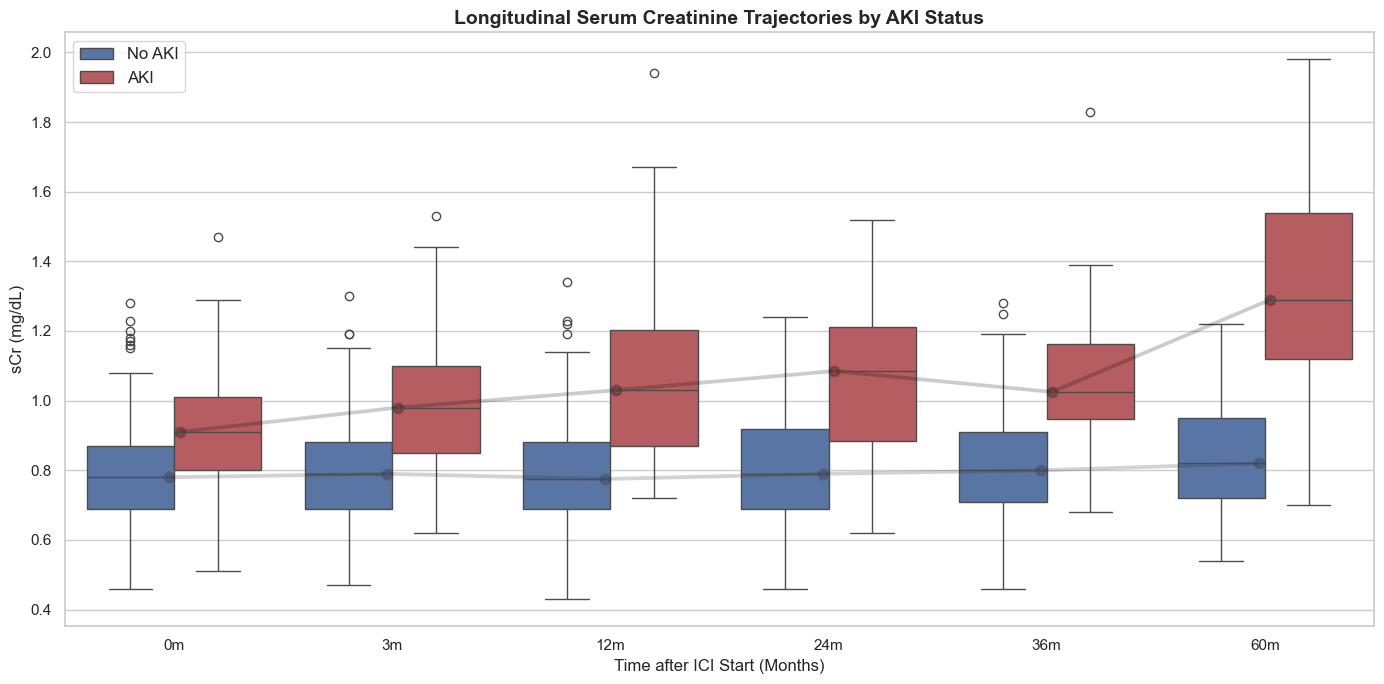

In [8]:
def plot_longitudinal_creatinine(df):

    """
    Visualizes longitudinal median serum creatinine trajectories stratified by AKI status.
    A pointplot overlay connects the median values of each group.

    Args:
        df (pd.DataFrame): The clinical dataset containing the 'AKI' binary flag, and sequential serum creatinine columns (e.g., 'cr_0m', 'cr_3m').

    Returns:
        None (Displays a matplotlib figure).
    """
    
    # Define creatinine columns 
    cr_cols = [c for c in df.columns if 'cr' in c]
    
    # Take only useful columns (AKI flag and creatinine columns)
    plot_df = df[['ID', 'AKI'] + cr_cols].copy()
    
    # Remap AKI flag for a cleaner legend 
    plot_df['AKI_label'] = plot_df['AKI'].map({0: 'No AKI', 1: 'AKI'})
    
    # From wide to long format
    melted_df = pd.melt(plot_df, id_vars=['ID', 'AKI_label'], value_vars=cr_cols, var_name='timepoint', value_name='sCr (mg/dL)')
    melted_df['timepoint'] = melted_df['timepoint'].str.replace('cr_', '')
    
    # Remove empty values 
    melted_df = melted_df.dropna(subset=['sCr (mg/dL)'])
    
    # Plotting
    plt.figure(figsize=(14, 7))
    sns.set_theme(style='whitegrid')
    ax = sns.boxplot(data=melted_df, x='timepoint', y='sCr (mg/dL)', hue='AKI_label', palette=AKI_palette, showfliers=True )

    # Pointplot to connect medians 
    sns.pointplot(data=melted_df, x='timepoint', y='sCr (mg/dL)', hue='AKI_label', estimator='median', errorbar=None, palette='dark:black', linestyles='-', markers='o',dodge=True, ax=ax, legend=False, alpha=0.2)
    
    # Formatting 
    plt.title('Longitudinal Serum Creatinine Trajectories by AKI Status', fontsize=14, fontweight='bold')
    plt.xlabel('Time after ICI Start (Months)', fontsize=12)
    plt.ylabel('sCr (mg/dL)', fontsize=12)
    plt.legend(title='', fontsize=12, loc='upper left') 
    plt.tight_layout()
    plt.show()

plot_longitudinal_creatinine(data)

### **Comment**
The median sCr is greater in the AKI group at each timestamp, from the beginning of the ICI therapy (0m) to the end of follow-up (60m), whereas it is almost constant (straight line) for the No AKI group.

**NOTE**

The median was chosen as the summary measure because sCr has a **right-skewed distribution** and the median is less influenced by extreme values and **outliers**.

### **1C.** Statistical testing

In [9]:
from scipy.stats import mannwhitneyu, chi2_contingency

Differences between the survival and death groups were assessed to determine whether the observed differences were statistically significant. 

Appropriate **statistical tests** were selected according to the type and distribution of each variable.

In [10]:
def stat_table(df, cont_vars, cat_vars, outcome_var):
    
    """
    Generates a baseline characteristics table stratified by a binary outcome variable.
    Computes descriptive statistics and appropriate hypothesis tests comparing two groups. 
    Continuous variables are summarized as Median [IQR] and compared using the Mann-Whitney U test. 
    Categorical variables are summarized as Counts (Percentages) and compared using the Chi-Square test.

    Args:
        df (pd.DataFrame): The dataset containing the variables.
        cont_vars (list of str): List of continuous variable column names.
        cat_vars (list of str): List of categorical variable column names.
        outcome_var (str): The binary column name used to stratify the groups (e.g., 'AKI' or 'death_flag').

    Returns:
        pd.DataFrame: A formatted descriptive statistics table containing variables, group-specific summaries, and calculated p-values.
    """
    
    rows = []
    
    # Subsets 
    df_subset_0 = df[df[outcome_var] == 0] 
    df_subset_1 = df[df[outcome_var] == 1]
    
    # Clean outcome name 
    out_name = outcome_var.replace('_flag', '').capitalize()
    col_0 = f'{out_name} = 0'
    col_1 = f'{out_name} = 1'

    # Continuous variables (Mann-Whitney U to avoid assumption about distribution) 
    for var in cont_vars:
        # Remove null values
        v0 = df_subset_0[var].dropna()
        v1 = df_subset_1[var].dropna()
        
        if len(v0) > 0 and len(v1) > 0:
            stat, p_val = mannwhitneyu(v0, v1, alternative='two-sided')
        else:
            p_val = np.nan
            
        # Median and Interquartile Range (IQR)
        val_0 = f'{v0.median():.1f} [{v0.quantile(0.25):.1f}-{v0.quantile(0.75):.1f}]'
        val_1 = f'{v1.median():.1f} [{v1.quantile(0.25):.1f}-{v1.quantile(0.75):.1f}]'
        
        rows.append({'Variable': var.replace('_', ' ').capitalize() if var[0].islower() else var.replace('_', ' '), col_0: val_0, col_1: val_1, 'P-value': f'{p_val:.3f}' if p_val >= 0.05 else f'< 0.05'})

    # Categorical variables (Chi-Square)
    for var in cat_vars:
        if var == outcome_var:
            continue
            
        # Contingency table (null values are automatically ignored)
        contingency_table = pd.crosstab(df[var], df[outcome_var])
        
        if contingency_table.size > 0:
            _, p_val, _, _ = chi2_contingency(contingency_table)
        else:
            p_val = np.nan
            
        rows.append({'Variable': var.replace('_', ' ').capitalize() if var[0].islower() else var.replace('_', ' '), col_0: '', col_1: '', 'P-value': f'{p_val:.3f}' if p_val >= 0.05 else f'< 0.05'})
        
        # Add row for each category with count and percentage 
        for category in contingency_table.index:
            count_0 = contingency_table.loc[category, 0] 
            count_1 = contingency_table.loc[category, 1] 
            
            pct_0 = (count_0 / len(df_subset_0) * 100) 
            pct_1 = (count_1 / len(df_subset_1) * 100) 
            
            rows.append({'Variable': f'  • {category}', col_0: f'{count_0} ({pct_0:.1f}%)', col_1: f'{count_1} ({pct_1:.1f}%)', 'P-value': ''})

    # Final DataFrame 
    results_table = pd.DataFrame(rows)
    return results_table

In [11]:
# Define categorical and continuous variables
cat_vars = ['gender', 'cancer_type', 'ICI_type', 'AKI', 'death_flag']
cont_vars = ['age', 'cr_0m']

# Example: compare dead and survival groups (it can be repeated by changing the outcome_var to 'AKI')
survival_vs_dead_table = stat_table(data, cont_vars, cat_vars, outcome_var='death_flag')
aki_vs_no_aki_table = stat_table(data, cont_vars, cat_vars, outcome_var='AKI')

In [12]:
survival_vs_dead_table

,Variable,Death = 0,Death = 1,P-value
0,Age,64.0 [57.0-71.0],63.0 [55.0-71.0],0.371
1,Cr 0m,0.8 [0.7-0.9],0.8 [0.7-0.9],0.056
2,Gender,,,0.495
3,• F,35 (36.1%),264 (40.3%),
4,• M,62 (63.9%),391 (59.7%),
5,Cancer type,,,< 0.05
6,• Lung,38 (39.2%),178 (27.2%),
7,• Melanoma,19 (19.6%),60 (9.2%),
8,• Other,23 (23.7%),291 (44.4%),
9,• Urogenital,17 (17.5%),126 (19.2%),


#### **Comment**
Statistically significant differences were observed between the survival and death groups in terms of **cancer type**, **ICI type**, and **AKI** status. 

For both cancer and ICI type, the the proportion of patients with **"Other"** are higher in the death group: 44.4% vs. 23.7% and 4.9% vs. 0.0%, respectively.

Additionally, **AKI** was more frequent in the death group (**15.9%** vs. 5.2%).

### **1D.** AKI vs No AKI Kaplan-Meier survival curves

In [13]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

The **Kaplan-Meier (KM) estimator** is a non-parametric statistic used to estimate the survival probability of a patient cohort over time. 

In this analysis, Kaplan-Meier curves are generated to visualize and compare the survival distributions across different patient subgroups. 

Specifically, the estimator is used to evaluate the overall survival probability of the **AKI group** compared to the **No AKI group**.

To determine whether the visual differences between the survival curves are statistically significant, the **log-rank test** is applied.

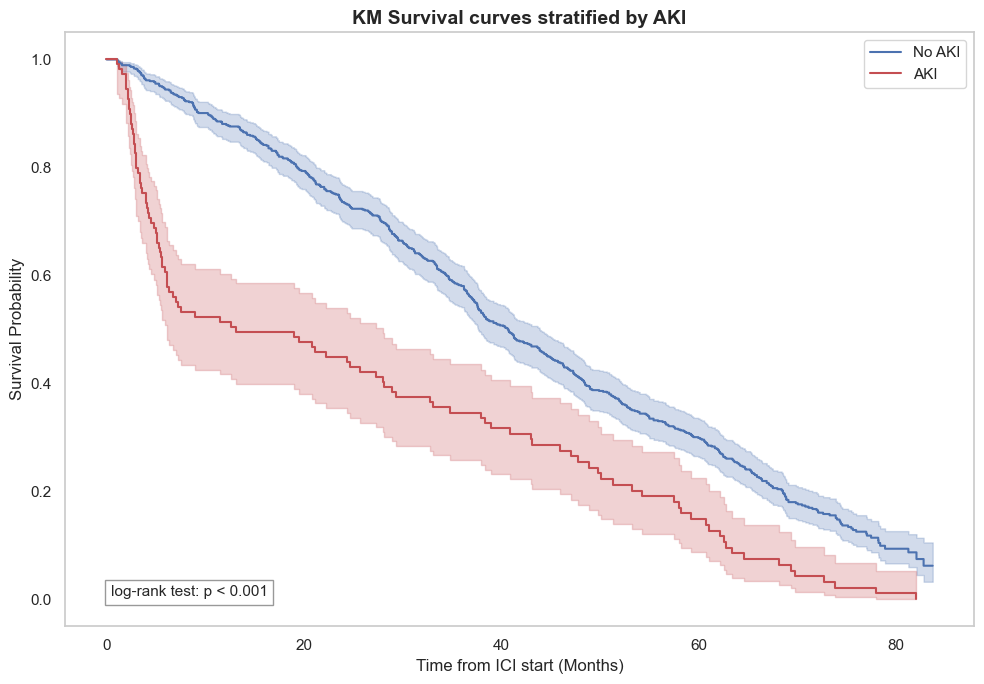

In [14]:
# Initialize Kaplan-Meier fitter
kmf = KaplanMeierFitter()

# Create duration column 
data['duration'] = (data['final_date'] - data['ICI_start']).dt.days / 30.44

# Divide into subsets
no_AKI_subset = data[data['AKI'] == 0]
AKI_subset = data[data['AKI'] == 1]

# Statistical test
results = logrank_test(AKI_subset['duration'], no_AKI_subset['duration'], event_observed_A=AKI_subset['death_flag'], event_observed_B=no_AKI_subset['death_flag'])
p = results.p_value

# Format p-value
if p < 0.001:
    p_text = 'p < 0.001'
else:
    p_text = f'p = {p:.3f}'

# Create figure 
plt.figure(figsize=(10, 7))

# Fit and plot for No AKI group
kmf.fit(durations=no_AKI_subset['duration'], event_observed=no_AKI_subset['death_flag'], label='No AKI')
kmf.plot_survival_function(color=AKI_palette[0])

# Fit and plot for AKI group
kmf.fit(durations=AKI_subset['duration'], event_observed=AKI_subset['death_flag'], label='AKI')
kmf.plot_survival_function(color=AKI_palette[1])

# Add log-rank test result
plt.text(0.05, 0.05, f'log-rank test: {p_text}', transform=plt.gca().transAxes, fontsize=11, fontstyle='normal', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# Formatting 
plt.grid(False)
plt.title('KM Survival curves stratified by AKI', fontsize=14, fontweight='bold')
plt.xlabel('Time from ICI start (Months)')
plt.ylabel('Survival Probability')
plt.tight_layout()
plt.show()

### **Comment**
The survival curve of the **AKI** group is steeper than the one of the No AKI group, especially in the first months after the start of therapy, suggesting that AKI is associated with **early mortality**.

This difference is statistically significant, considering that **p < 0.001** for the **log-rank test**.

## **2. COX PROPORTIONAL HAZARDS MODEL**

The **Cox Proportional Hazards model** is a widely used survival analysis technique that explores the relationship between the survival time of a patient and one or more predictor variables (covariates). 

Unlike other parametric models, it does not require assuming a specific statistical distribution for the underlying survival times. 

In this pipeline, the model is employed to evaluate the prognostic impact of clinical covariates on **mortality**.

Furthermore, a **time-varying** framework is utilized to model the occurrence of AKI as a dynamic event, rather than a baseline feature, effectively mitigating **immortal time bias**.

The primary output of a Cox model is the **Hazard Ratio (HR)**, which quantifies the relative risk of an event occurring due to a one-unit change in the predictor variable, or when comparing one category to a reference group.

* **HR = 1**: The predictor has no effect on the hazard (risk of the event).
* **HR > 1**: The predictor is associated with an increased risk, indicating a harmful effect.
* **HR < 1**: The predictor is associated with a decreased risk, indicating a protective effect.

The HR is typically evaluated alongside its **95% Confidence Interval (CI)** and a **P-value** to determine statistical significance.

### **2A.** Static Cox model

In [15]:
from lifelines import CoxPHFitter

In [16]:
# Select baseline variables and AKI
cox_cols = ['age', 'gender', 'cr_0m', 'cancer_type', 'ICI_type', 'AKI', 'death_flag', 'duration']

# Copy of the original DataFrame 
cox_data = data[cox_cols].copy()

# Categorical variables must be converted into dummies 
var_to_convert = ['cancer_type', 'ICI_type']

for var in var_to_convert:
    cox_data = pd.get_dummies(cox_data, columns=[var], prefix='', prefix_sep='', dtype=int)
    # Exclude the Other category to make it a reference 
    cox_data = cox_data.drop(columns='Other')

# Map gender
cox_data['gender'] = cox_data['gender'].map({'M':1, 'F': 0})

# Check
# cox_data.head(10)

In [17]:
# Initialize Cox model
cph = CoxPHFitter()

# Fit the model 
cph.fit(cox_data, duration_col='duration', event_col='death_flag')

# Print summary
# cph.print_summary()

<lifelines.CoxPHFitter: fitted with 752 total observations, 97 right-censored observations>

In [18]:
def plot_cox(cox_model, cox_type, var):
    
    """
    Generates a forest plot of Hazard Ratios (HR) and 95% Confidence Intervals from a Cox model, highlighting a specific variable of interest.

    Args:
        cox_model: A fitted Cox proportional hazards model object.
        cox_type (str): A descriptor for the model type (e.g., 'Static' or 'Time-Varying') used to dynamically format the plot title.
        var (str): The name of the covariate to highlight in the plot.

    Returns:
        None (Displays a matplotlib figure).
    """
    
    # Extract summary and variables
    summary = cox_model.summary
    variables = summary.index.tolist()
    variables = [v.capitalize().replace('_', ' ') if v[0].islower() else v for v in variables]

    # Extract Hazard Ratio and 95% CI
    hr = summary['exp(coef)']
    lower = summary['exp(coef) lower 95%']
    upper = summary['exp(coef) upper 95%']

    # Calculate errors (distance from HR to confidence bounds)
    xerr = np.array([hr - lower, upper - hr])

    fig, ax = plt.subplots(figsize=(10, 7))
    y_pos = np.arange(len(variables))

    # Plot all variables with standard black color
    ax.errorbar(x=hr, y=y_pos, xerr=xerr, fmt='s', color='black', ecolor='black', elinewidth=1.5, capsize=4, markersize=6, zorder=2)

    # Set the variables names on the Y-axis
    ax.set_yticks(y_pos)
    ax.set_yticklabels(variables)
    ax.invert_yaxis() 
    
    ax.set_title(f'{cox_type} Cox Model Results', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Hazard Ratio (95% CI)', fontsize=12)

    # Remove top and right spines 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')

    # No grid, add a reference line for HR = 1
    ax.grid(False)
    ax.axvline(x=1, color='black', linestyle=':', alpha=0.6, zorder=1)

    # Highlight the selected variable
    if var in variables:
        var_index = variables.index(var)
        var_hr = hr.iloc[var_index]
        
        # Estrae il limite superiore dell'intervallo di confidenza per posizionare il testo
        var_upper = upper.iloc[var_index] 
        
        # Highlight the row background
        ax.axhspan(var_index - 0.4, var_index + 0.4, color='#ff9999', alpha=0.3, zorder=0)     
        ax.errorbar(x=var_hr, y=var_index, xerr=np.array([[xerr[0][var_index]], [xerr[1][var_index]]]), fmt='s', color='red', ecolor='red', elinewidth=2, capsize=4, markersize=7, zorder=3)
    
        # Make Y-label red and bold
        ax.get_yticklabels()[var_index].set_color('red')
        ax.get_yticklabels()[var_index].set_fontweight('bold')
        
        # Draw a full vertical dashed red line
        ax.axvline(x=var_hr, color='red', linestyle=':', alpha=0.6, zorder=1)
        ax.text(var_hr + 0.15, var_index + 0.5, f"{var_hr:.2f}", color='red', fontweight='bold', va='top', ha='center', fontsize=11, zorder=4)

    plt.tight_layout()

    # Show the plot
    plt.show()

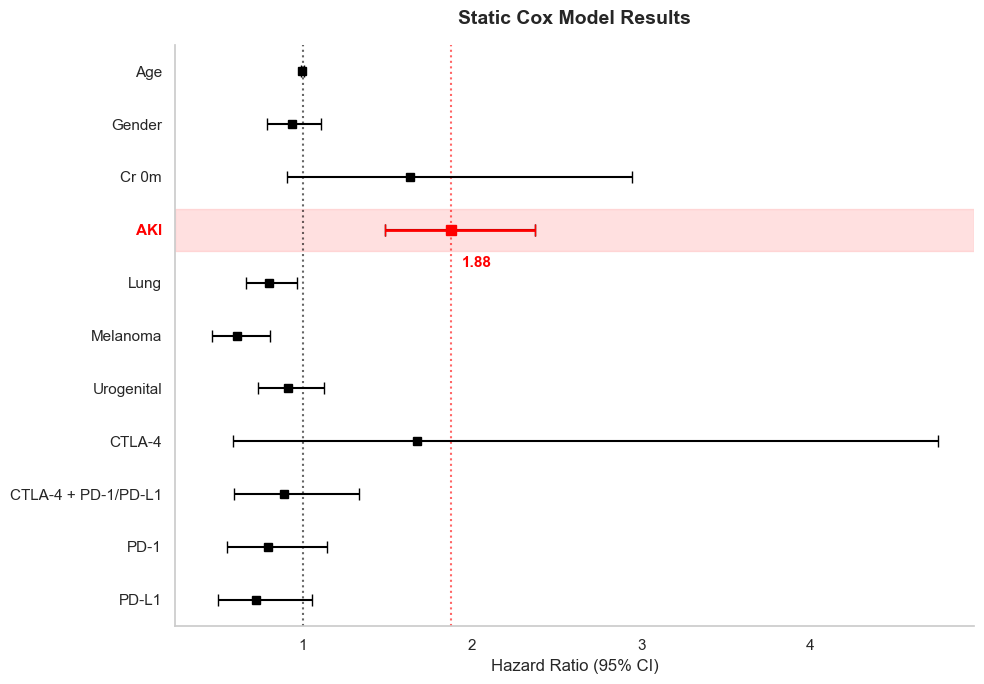

In [19]:
# Forest plot for the static model
plot_cox(cph, 'Static', 'AKI')

#### **Comment**
The **AKI** variable is completely on the right with respect to the $x = 1$ line, meaning that this covariate is significantly associated with an increased probability of the outcome.

The **Lung** and **Melanoma** types of cancer are completely on the left with respect to the $x = 1$ line, meaning that they are protective with respect to the reference category ('Other').

### **2B.** Time-varying Cox model

In [20]:
from lifelines import CoxTimeVaryingFitter

To accurately assess the mortality risk associated with AKI and mitigate **immortal time bias**, AKI must be modeled as a dynamic covariate. 

This requires transforming the standard dataset into a **long format**. 

For patients who experience an AKI episode, their total follow-up time is split into two distinct rows:
* **Unexposed Period (AKI = 0)**: from the start of ICI therapy to the date of the AKI diagnosis
* **Exposed Period (AKI = 1)**: from the date of the AKI diagnosis to the end of follow-up (or death)

In [21]:
def long_format(df, split_col):
    
    """
    Transforms a wide-format clinical dataset into a long format, by splitting the follow-up period into two intervals (pre-event and post-event) for patients experiencing the event.

    Args:
        df (pd.DataFrame): The original wide-format clinical dataset.
        split_col (str): The name of the binary column representing the event (e.g., 'AKI').

    Returns:
        pd.DataFrame: The transformed dataset in long format featuring 'start', 'stop', and the updated event flag columns.
    """

    long_df_rows = []
    
    for _, row in df.iterrows():
        # Constant information
        ID = row['ID']
        age = row['age']
        gender = row['gender']
        cr_0m = row['cr_0m']
        cancer_type = row['cancer_type']
        ICI_type = row['ICI_type'] 
        death_flag = row['death_flag']

        # Time information
        ICI_start = row['ICI_start']
        AKI_date = row['AKI_date']
        end_follow_up = row['final_date']
        
        # If patient has AKI, the row is split into two rows: one from ICI start to AKI diagnosis (AKI = 0), one from AKI diagnosis to end of follow-up/death (AKI = 1)
        if row[split_col] == 1:
            first_row = {'ID': ID, 'start': ICI_start, 'age':age, 'gender': gender, 'cr_0m': cr_0m, 'cancer_type': cancer_type, 'ICI_type': ICI_type, split_col: 0, 'death_flag': 0, 'stop': AKI_date}
            long_df_rows.append(first_row)
            second_row = {'ID': ID, 'start': AKI_date, 'age':age, 'gender': gender, 'cr_0m': cr_0m, 'cancer_type': cancer_type, 'ICI_type': ICI_type, split_col: 1, 'death_flag': death_flag, 'stop': end_follow_up}
            long_df_rows.append(second_row)
            
        else:
            row = {'ID': ID, 'start': ICI_start, 'age':age, 'gender': gender, 'cr_0m': cr_0m, 'cancer_type': cancer_type, 'ICI_type': ICI_type, split_col: 0, 'death_flag': death_flag, 'stop': end_follow_up}
            long_df_rows.append(row)

    long_df = pd.DataFrame(long_df_rows)
    
    return long_df

long_df_cox = long_format(data, 'AKI')

In [22]:
# Categorical variables must be converted into dummies 
var_to_convert = ['cancer_type', 'ICI_type']

for var in var_to_convert:
    long_df_cox = pd.get_dummies(long_df_cox, columns=[var], prefix='', prefix_sep='', dtype=int)
    
    # Exclude the 'Other' category to make it a reference 
    long_df_cox = long_df_cox.drop(columns='Other')

# Map gender
long_df_cox['gender'] = long_df_cox['gender'].map({'M':1, 'F': 0})

# Check
# long_df_cox.sample(10)

# NOTE
# The duration column is not necessary, having start and stop

In [23]:
# Initialize Time-varying Cox model
ctv = CoxTimeVaryingFitter()

# Fit the model
ctv.fit(long_df_cox, id_col='ID', event_col='death_flag', start_col='start', stop_col='stop')

# Print summary
# ctv.print_summary()

<lifelines.CoxTimeVaryingFitter: fitted with 861 periods, 752 subjects, 655 events>

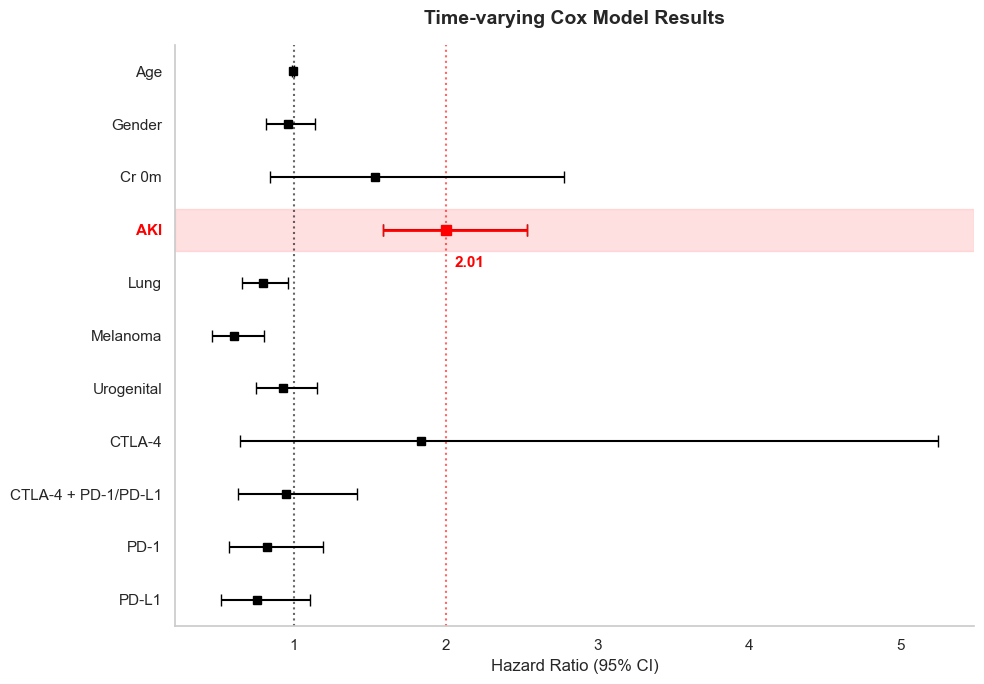

In [24]:
# Forest plot for the time-varying model
plot_cox(ctv, 'Time-varying', 'AKI')

### **Comment**
Treating **AKI** as a time-varying covariate, the immortal time bias is mitigated and the patients are considered as exposed only after the actual diagnosis.

The result is an increse of the **HR**: 

* **$HR_{AKI}$** : **1.88** **->** **2.01**

This transformation prevents the model from artificially granting a survival advantage to the AKI group during the unexposed period.

## **3. LINEAR MIXED EFFECTS MODEL**

### **3A.** Estimate of glomerular filtration rate 

The **2021 CKD-EPI (Chronic Kidney Disease Epidemiology Collaboration)** equation is the currently recommended standard for estimating the Glomerular Filtration Rate (eGFR) from serum creatinine (sCr). 

Notably, this updated 2021 version is a **race-free** equation, eliminating the race multiplier to provide a universally applicable assessment of kidney function.

The mathematical formulation is:

$$ \text{eGFR} = 142 \times \min\left(\frac{\text{sCr}}{\kappa}, 1\right)^\alpha \times \max\left(\frac{\text{sCr}}{\kappa}, 1\right)^{-1.200} \times 0.9938^{\text{Age}} \times (1.012 \text{ if Female}) $$

Where:
* **eGFR**: Estimated Glomerular Filtration Rate ($mL/min/1.73m^2$), **sCr**: Serum creatinine (mg/dL)
* **$\kappa$**: $0.7$ for females and $0.9$ for males, **$\alpha$**: $-0.241$ for females and $-0.302$ for males
* **Age**: Age in years

In [25]:
# Select creatinine cols
cr_cols = [c for c in data.columns if 'cr' in c]

In [26]:
def CKD_EPI_2021(df, age_col, gender_col, cr_cols):

    """
    Calculates the estimated Glomerular Filtration Rate (eGFR) using the race-free CKD-EPI 2021 equation.
    
    Args:
        df (pd.DataFrame): The clinical dataset containing demographic and creatinine data.
        age_col (str): The column name representing patient age in years.
        gender_col (str): The column name representing biological sex ('M' or 'F').
        cr_cols (list of str): A list of column names containing serum creatinine measurements (in mg/dL).

    Returns:
        pd.DataFrame: The original DataFrame updated with new corresponding eGFR columns (e.g., 'cr_3m' generates 'eGFR_3m').
    """

    age = df[age_col].astype(float)
    sex = df[gender_col]

    # Sex-specific parameters
    kappa = sex.map({'F': 0.7, 'M': 0.9})
    alpha = sex.map({'F': -0.241, 'M': -0.302})
    sex_factor = sex.map({'F': 1.012, 'M': 1.0})

    # Calculate eGFR for each creatinine measurement
    for c in cr_cols:

        scr = df[c].astype(float)

        scr_k = scr / kappa

        egfr = (142 * scr_k.clip(upper=1) ** alpha * scr_k.clip(lower=1) ** -1.200 * (0.9938 ** age) * sex_factor)

        # New column
        df[f'eGFR_{c.replace('cr_', '')}'] = egfr

    return df

egfr_data = CKD_EPI_2021(data, age_col='age', gender_col='gender', cr_cols=cr_cols)

# Check
# egfr_data.sample(10)

### **3B.** Model implementation

In [27]:
import statsmodels.formula.api as smf

Real-world longitudinal data often feature an unbalanced number of measurements per patient and irregular time intervals between visits. 

**Linear Mixed-Effects Models (LMMs)** account for population-level trends (fixed effects) and individual patient variability (random effects), being the optimate tool for this analysis.

The mathematical formulation of the model, with a **random intercept**, correcting for age and gender, is defined as follows:

$$\text{eGFR}_{ij} = \beta_0 + \beta_1 \cdot \text{time}_{ij} + \beta_2 \cdot \text{AKI}_i + \beta_3 \cdot (\text{time}_{ij} \times \text{AKI}_i) + \beta_4 \cdot \text{Age}_{i} + \beta_5 \cdot \text{Gender}_i + b_{0i} + \epsilon_{ij}$$

Where:
* **$\text{eGFR}_{ij}$**: The estimated eGFR value for patient $i$ at time $j$.
* **$\beta_0$ (Intercept)**: The baseline average eGFR for the reference group.
* **$\beta_1$ (Time)**: The annual eGFR decline rate for patients in the reference group.
* **$\beta_2$ (AKI)**: The baseline difference in eGFR between patients with AKI and those without AKI at the start of the observation.
* **$\beta_3$ (Time $\times$ AKI)**: The crucial interaction term for the study. It represents the difference in the annual decline rate between patients with AKI and the control group.
* **$\beta_4, \beta_5$**: The adjustment coefficients for age (centered around the mean) and gender.
* **$b_{0i}$ (Random Intercept)**: The patient-specific random effect, allowing each patient to have a different starting point (intercept).
* **$\epsilon_{ij}$**: The residual error for the specific measurement.

In [28]:
# Select eGFR cols
egfr_cols = [c for c in egfr_data.columns if 'eGFR' in c]

In [29]:
# Convert to LMM-friendly format 
melted_df = egfr_data.melt(id_vars=['ID', 'age', 'gender', 'AKI'], value_vars=egfr_cols, var_name='time_label', value_name='eGFR')

# Extract month from time_label
melted_df['time'] = (melted_df['time_label'].str.replace('eGFR_', '').str.replace('m', '')).astype(int)
melted_df = melted_df.drop(columns='time_label')

# Exclude empty observations
melted_df = melted_df.dropna(subset=['eGFR'])

# Convert time to years 
melted_df['time'] = melted_df['time'] / 12.0

# Center age around the mean value
melted_df['age_centered'] = melted_df['age'] - melted_df['age'].mean()

# Map gender
melted_df['gender'] = melted_df['gender'].map({'M':1, 'F': 0})

# Check
# melted_df.sample(10)

In [30]:
# Formula
formula = 'eGFR ~ time * AKI + age_centered + gender'

# Create the model
model_RI = smf.mixedlm(formula, data=melted_df,groups=melted_df['ID'], re_formula='1')

# Fit the model
result_RI = model_RI.fit(reml=False, method='lbfgs')

print(result_RI.summary())

           Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  eGFR      
No. Observations:  2967     Method:              ML        
No. Groups:        752      Scale:               22.0319   
Min. group size:   1        Log-Likelihood:      -9821.5942
Max. group size:   6        Converged:           Yes       
Mean group size:   3.9                                     
-----------------------------------------------------------
              Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept     91.920    0.582 158.003 0.000  90.780  93.060
time          -1.017    0.071 -14.321 0.000  -1.156  -0.877
AKI          -12.678    1.034 -12.259 0.000 -14.705 -10.651
time:AKI      -3.230    0.245 -13.166 0.000  -3.711  -2.749
age_centered  -0.610    0.032 -19.089 0.000  -0.672  -0.547
gender         5.611    0.719   7.800 0.000   4.201   7.021
Group Var     86.421    1.184                      

### **Comment**
The **Time × AKI** interaction is statistically significant, with a coefficient of −3.230, indicating that patients with AKI experience a significantly faster decline in eGFR over time.

Specifically, the estimated annual change in eGFR is:

* **1.017** $mL/min/1.73 m^2$ per year in patients without AKI

* −1.017 − 3.230 = **−4.247** $mL/min/1.73 m^2$ per year in patients with AKI.

The presence of AKI is associated with an additional decline in eGFR of 3.230 $mL/min/1.73 m^2$ per year compared with patients without AKI.

### **3C.** Visual representation

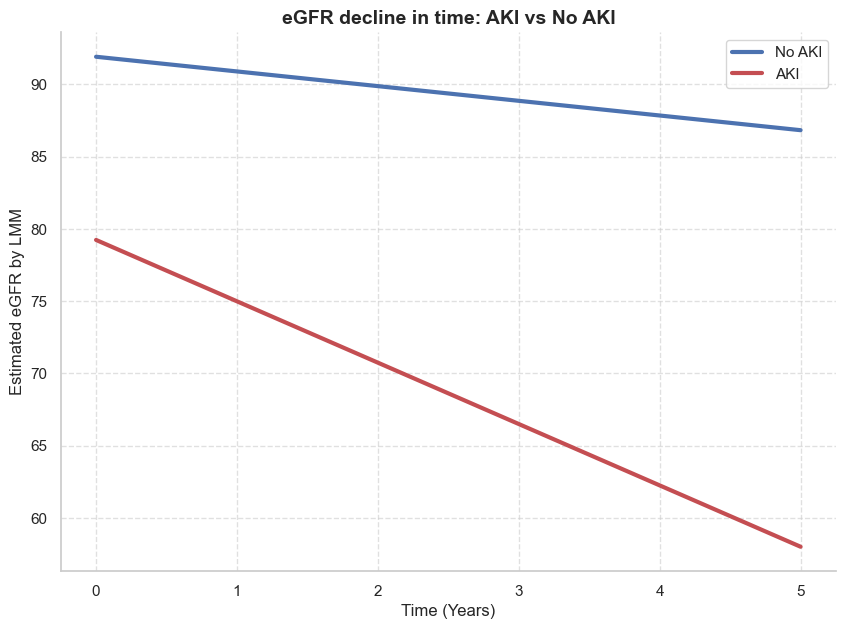

In [31]:
# Define temporal range and select 100 points
t_min = melted_df['time'].min()
t_max = melted_df['time'].max()
time_points = np.linspace(t_min, t_max, 100)

# Synthetic dataset for prediction: age fixed to 0(mean age) and gender to 0 (Female)
df_pred = pd.DataFrame({'time': np.concatenate([time_points, time_points]), 'AKI': np.concatenate([np.zeros(100), np.ones(100)]), 'age_centered': 0, 'gender': 0})

# Calculate eGFR using the fitted model
df_pred['eGFR_predicted'] = result_RI.predict(df_pred)

# Clear legend
df_pred['Group'] = df_pred['AKI'].map({0.0: 'No AKI', 1.0: 'AKI'})

# Plot 
plt.figure(figsize=(10, 7))
sns.lineplot(data=df_pred, x='time', y='eGFR_predicted', hue='Group', linewidth=3, palette=AKI_palette)

# Formatting
plt.title('eGFR decline in time: AKI vs No AKI', fontsize=14, fontweight='bold')
plt.xlabel('Time (Years)', fontsize=12)
plt.ylabel('Estimated eGFR by LMM', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True)
sns.despine() # Rimuove i bordi superiore e destro per un look più pulito

plt.show()

# NOTE
# The same plot can be generated for a male patient, changing gender to 1 